# Reinforcement Learning for Autonomous Driving with PPO

In this notebook, I'm experimenting with reinforcement learning to train an autonomous driving agent in the HighwayEnv simulation. The goal is to learn a driving policy that maximizes speed while avoiding collisions. I'm using Proximal Policy Optimization (PPO), a popular policy-gradient algorithm.

---

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import gymnasium as gym
import highway_env

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv

from env_factory import make_env
from config import ENV_CONFIG, REWARD_CONFIG

## Experiment Configuration

All important parameters can be modified directly in this notebook.

This allows quick experimentation without modifying the project source files.

In [155]:
TARGET_EPISODES = 2000
N_ENVS = 1

LEARNING_RATE = 3e-4
GAMMA = 0.99

MODEL_PATH = "models/ppo_highway_simple.zip"

## Environment Creation

We now create the HighwayEnv environment with a custom reward function.

The reward encourages high speed while penalizing collisions.

In [156]:
# reward_config = {
#     "w_speed": 2.0,
#     "w_progress": 1000.0,
#     "w_collision": 17.0,
#     "w_too_close": 2.0,
#     "w_action_change": 2.0,
#     "w_overtake": 1000.0,
#     "v_min": 27.0,
#     "v_max": 50.0,
#     "d_safe": 32.0,
#     "side_window": 15.0,
#     "pass_margin": 5.0,
#     "w_lonely": 8.0,
#     "rear_window": 30.0,

# }

TARGET_EPISODES = 1000

reward_config = {

    "w_speed": 3.0,
    "w_progress": 8.0,
    "w_collision": 20.0,
    "w_too_close": 2.0,
    "w_action_change": 0,
    "w_overtake": 0,

    "v_min": 20.0,
    "v_max": 40.0,
    "d_safe": 20.0,

    "side_window": 0,
    "pass_margin": 0,

    "w_lonely": 0,
    "rear_window": 0,
    "w_being_overtaken": 0
}


def env_fn():
    return Monitor(make_env(ENV_CONFIG, reward_config))

env = DummyVecEnv([env_fn for _ in range(N_ENVS)])

## PPO Model Initialization

The policy is represented by a neural network that outputs action probabilities.

Stable-Baselines3 provides a reliable PPO implementation.

In [157]:
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    ent_coef=0.01,
    verbose=0,
    tensorboard_log="./tensorboard/",
    batch_size=128,
)

## Training Monitoring

To observe the training process we implement a custom callback that prints episode statistics during training.

In [158]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

class EpisodeLogger(BaseCallback):
    def __init__(self, target_episodes):
        super().__init__()
        self.target_episodes = target_episodes
        self.episode_rewards = []
        self.episode_lengths = []
        self.mean_rewards = []
        self.mean_lengths = []
        self.episode_count = 0

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])

        for info in infos:
            if "episode" in info:
                ep_info = info["episode"]
                r = ep_info["r"]
                l = ep_info["l"]

                self.episode_count += 1
                self.episode_rewards.append(r)
                self.episode_lengths.append(l)

                recent_rewards = self.episode_rewards[-20:]
                recent_lengths = self.episode_lengths[-20:]

                mean_r = np.mean(recent_rewards)
                self.mean_rewards.append(mean_r)
                mean_l = np.mean(recent_lengths)
                self.mean_lengths.append(mean_l)

                print(
                    f"Episode {self.episode_count}/{self.target_episodes} | "
                    f"Reward: {r:.2f} | "
                    f"Length: {l} | "
                    f"MeanReward(20): {mean_r:.2f} | "
                    f"MeanLength(20): {mean_l:.2f}"
                )

                if self.episode_count >= self.target_episodes:
                    print("\nTarget number of episodes reached. Stopping training.")
                    return False

        return True

logger = EpisodeLogger(target_episodes=TARGET_EPISODES)

## Training the Agent

We now train the PPO agent.

During training, episode statistics will be printed to monitor learning progress.

In [159]:
model.learn(
    total_timesteps=10_000_000,
    callback=logger
)

model.save("models/ppo_highway_simple_phase1.zip")

Episode 1/1000 | Reward: 604.76 | Length: 7 | MeanReward(20): 604.76 | MeanLength(20): 7.00
Episode 2/1000 | Reward: 242.17 | Length: 3 | MeanReward(20): 423.47 | MeanLength(20): 5.00
Episode 3/1000 | Reward: 333.81 | Length: 4 | MeanReward(20): 393.58 | MeanLength(20): 4.67
Episode 4/1000 | Reward: 301.20 | Length: 4 | MeanReward(20): 370.48 | MeanLength(20): 4.50
Episode 5/1000 | Reward: 324.34 | Length: 4 | MeanReward(20): 361.26 | MeanLength(20): 4.40
Episode 6/1000 | Reward: 1585.20 | Length: 21 | MeanReward(20): 565.25 | MeanLength(20): 7.17
Episode 7/1000 | Reward: 1002.71 | Length: 13 | MeanReward(20): 627.74 | MeanLength(20): 8.00
Episode 8/1000 | Reward: 998.76 | Length: 12 | MeanReward(20): 674.12 | MeanLength(20): 8.50
Episode 9/1000 | Reward: 776.87 | Length: 11 | MeanReward(20): 685.54 | MeanLength(20): 8.78
Episode 10/1000 | Reward: 819.62 | Length: 9 | MeanReward(20): 698.94 | MeanLength(20): 8.80
Episode 11/1000 | Reward: 1442.00 | Length: 21 | MeanReward(20): 766.49 |

In [ ]:
import os
import gc
import imageio.v2 as imageio

os.makedirs("videos", exist_ok=True)

env_video = make_env(ENV_CONFIG, reward_config, render_mode="rgb_array")

obs, _ = env_video.reset()

frames = []
done = False
max_frames = 800

# first frame
frame = env_video.render()
if frame is not None:
    frames.append(frame)

while not done and len(frames) < max_frames:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_video.step(action)

    frame = env_video.render()
    if frame is not None:
        frames.append(frame)

    done = terminated or truncated

video_path = "videos/simple_advancement_phase1.mp4"

print("Number of collected frames:", len(frames))

if len(frames) == 0:
    raise RuntimeError("No frames were collected. Check render_mode and make_env().")

imageio.mimsave(video_path, frames, fps=15)

env_video.close()

del obs
del frames

gc.collect()


print(f"Saved video to {video_path}")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Number of collected frames: 800
Saved video to videos/simple_advancement_phase1.mp4


In [167]:
from IPython.display import Video

Video("videos/simple_advancement_phase1.mp4", embed=True)

In [118]:
# reward_config = {
#     "w_speed": 2.0,
#     "w_progress": 1000.0,
#     "w_collision": 17.0,
#     "w_too_close": 2.0,
#     "w_action_change": 2.0,
#     "w_overtake": 1000.0,
#     "v_min": 27.0,
#     "v_max": 50.0,
#     "d_safe": 32.0,
#     "side_window": 15.0,
#     "pass_margin": 5.0,
#     "w_lonely": 8.0,
#     "rear_window": 30.0,

# }

TARGET_EPISODES = 4000
logger = EpisodeLogger(target_episodes=TARGET_EPISODES)

reward_config = {

    "w_speed": 2.0,
    "w_progress": 3.0,
    "w_collision": 20.0,
    "w_too_close": 2.0,
    "w_action_change": 0.5,
    "w_overtake": 7.0,

    "v_min": 25.0,
    "v_max": 40.0,
    "d_safe": 15.0,

    "side_window": 15.0,
    "pass_margin": 5.0,

    "w_lonely": 0,
    "rear_window": 30.0,
    "w_being_overtaken": 6.0

}


def env_fn():
    return Monitor(make_env(ENV_CONFIG, reward_config))

env = DummyVecEnv([env_fn for _ in range(N_ENVS)])

# model = PPO(
#     "MlpPolicy",
#     env,
#     learning_rate=LEARNING_RATE,
#     gamma=GAMMA,
#     ent_coef=0.15,
#     verbose=0,
#     tensorboard_log="./tensorboard/",
#     batch_size=128,
# )

model.learn(
    total_timesteps=10_000_000,
    callback=logger
)

model.save("models/ppo_highway_simple_phase2.zip")

env_video = make_env(ENV_CONFIG, reward_config, render_mode="rgb_array")

obs, _ = env_video.reset()

frames = []
done = False
max_frames = 800

# première frame
frame = env_video.render()
if frame is not None:
    frames.append(frame)

while not done and len(frames) < max_frames:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_video.step(action)

    frame = env_video.render()
    if frame is not None:
        frames.append(frame)

    done = terminated or truncated

video_path = "videos/simple_advancement_phase2.mp4"

print("Number of collected frames:", len(frames))

if len(frames) == 0:
    raise RuntimeError("No frames were collected. Check render_mode and make_env().")

imageio.mimsave(video_path, frames, fps=15)

env_video.close()

del obs
del frames
gc.collect()


print(f"Saved video to {video_path}") 
from IPython.display import Video

Video("videos/simple_advancement_phase2.mp4", embed=True)

Episode 1/4000 | Reward: 389.70 | Length: 13 | MeanReward(20): 389.70 | MeanLength(20): 13.00
Episode 2/4000 | Reward: 218.02 | Length: 10 | MeanReward(20): 303.86 | MeanLength(20): 11.50
Episode 3/4000 | Reward: 230.43 | Length: 8 | MeanReward(20): 279.38 | MeanLength(20): 10.33
Episode 4/4000 | Reward: 298.00 | Length: 14 | MeanReward(20): 284.03 | MeanLength(20): 11.25
Episode 5/4000 | Reward: 123.93 | Length: 5 | MeanReward(20): 252.01 | MeanLength(20): 10.00
Episode 6/4000 | Reward: 161.29 | Length: 6 | MeanReward(20): 236.89 | MeanLength(20): 9.33
Episode 7/4000 | Reward: 597.54 | Length: 22 | MeanReward(20): 288.41 | MeanLength(20): 11.14
Episode 8/4000 | Reward: 237.09 | Length: 9 | MeanReward(20): 282.00 | MeanLength(20): 10.88
Episode 9/4000 | Reward: 1122.82 | Length: 36 | MeanReward(20): 375.42 | MeanLength(20): 13.67
Episode 10/4000 | Reward: 476.52 | Length: 16 | MeanReward(20): 385.53 | MeanLength(20): 13.90
Episode 11/4000 | Reward: 611.86 | Length: 21 | MeanReward(20):

KeyboardInterrupt: 

# Training in 2 Phases

I'm training the model in two phases to improve it step by step.

In [4]:
TARGET_EPISODES_PHASE1 = 1000
TARGET_EPISODES_PHASE2 = 200

N_ENVS = 1
LEARNING_RATE = 3e-4
GAMMA = 0.99

MODEL_PHASE1_PATH = "models/ppo_phase1"
MODEL_PHASE2_PATH = "models/ppo_phase2"

In [6]:
REWARD_CONFIG_PHASE1 = {
    "alpha": 2.0,
    "beta": 20.0,
    "gamma_safe": 0,
    "delta_lane": 0.0,
    "eta_smooth": 0.0,
    "blocked_weight": 0.0,
    "v_min": 20.0,
    "v_max": 40.0,
    "d_safe": 15.0,
}

REWARD_CONFIG_PHASE2 = {
    "alpha": 3.0,
    "beta": 15.0,
    "gamma_safe": 1.5,
    "delta_lane": 0.03,
    "eta_smooth": 0.08,
    "blocked_weight": 0.5,
    "v_min": 20.0,
    "v_max": 30.0,
    "d_safe": 18.0,
}

In [5]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

class EpisodeLogger(BaseCallback):
    def __init__(self, target_episodes):
        super().__init__()
        self.target_episodes = target_episodes
        self.episode_rewards = []
        self.episode_lengths = []
        self.mean_rewards = []
        self.mean_lengths = []
        self.episode_count = 0

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])

        for info in infos:
            if "episode" in info:
                ep_info = info["episode"]
                r = ep_info["r"]
                l = ep_info["l"]

                self.episode_count += 1
                self.episode_rewards.append(r)
                self.episode_lengths.append(l)

                mean_r = np.mean(self.episode_rewards[-20:])
                mean_l = np.mean(self.episode_lengths[-20:])
                self.mean_rewards.append(mean_r)
                self.mean_lengths.append(mean_l)

                print(
                    f"Episode {self.episode_count}/{self.target_episodes} | "
                    f"Reward: {r:.2f} | Length: {l} | "
                    f"MeanReward(20): {mean_r:.2f} | "
                    f"MeanLength(20): {mean_l:.2f}"
                )

                if self.episode_count >= self.target_episodes:
                    print("\nTarget number of episodes reached. Stopping training.")
                    return False

        return True

### Phase 1 

In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

def env_fn_phase1():
    return Monitor(make_env(ENV_CONFIG, REWARD_CONFIG_PHASE1))

env_phase1 = DummyVecEnv([env_fn_phase1 for _ in range(N_ENVS)])

model = PPO(
    "MlpPolicy",
    env_phase1,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    verbose=0,
    tensorboard_log="./tensorboard/"
)

logger_phase1 = EpisodeLogger(target_episodes=TARGET_EPISODES_PHASE1)

model.learn(
    total_timesteps=10_000_000,
    callback=logger_phase1
)

model.save(MODEL_PHASE1_PATH)
print("Phase 1 saved.")

NameError: name 'REWARD_CONFIG_PHASE1' is not defined

In [7]:
from stable_baselines3 import PPO
import os

# chemin vers le modèle
MODEL_PATH = "models/ppo_phase1.zip"

# vérification que le fichier existe
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

# chargement du modèle
model = PPO.load(MODEL_PATH)

print("Model loaded successfully.")

Model loaded successfully.


In [8]:
TARGET_EPISODES_PHASE2 = 300
REWARD_CONFIG_PHASE2 = {
    "alpha": 0.0,
    "beta": 20.0,
    "gamma_safe": 2.0,
    "delta_lane": 2.5,
    "eta_smooth": 0.7,
    "blocked_weight": 5.0,
    "v_min": 20.0,
    "v_max": 40.0,
    "d_safe": 15.0,
}

### Phase 2 : fine tuning

In [9]:
def env_fn_phase2():
    return Monitor(make_env(ENV_CONFIG, REWARD_CONFIG_PHASE2))

env_phase2 = DummyVecEnv([env_fn_phase2 for _ in range(N_ENVS)])

model = PPO.load(MODEL_PHASE1_PATH, env=env_phase2)

logger_phase2 = EpisodeLogger(target_episodes=TARGET_EPISODES_PHASE2)

model.learn(
    total_timesteps=10_000_000,
    callback=logger_phase2,
    reset_num_timesteps=False
)

model.save(MODEL_PHASE2_PATH)
print("Phase 2 saved.")

Episode 1/300 | Reward: -2809.28 | Length: 1000 | MeanReward(20): -2809.28 | MeanLength(20): 1000.00
Episode 2/300 | Reward: -3526.34 | Length: 1000 | MeanReward(20): -3167.81 | MeanLength(20): 1000.00
Episode 3/300 | Reward: -3634.86 | Length: 1000 | MeanReward(20): -3323.49 | MeanLength(20): 1000.00
Episode 4/300 | Reward: -3060.33 | Length: 1000 | MeanReward(20): -3257.70 | MeanLength(20): 1000.00
Episode 5/300 | Reward: -2789.23 | Length: 1000 | MeanReward(20): -3164.01 | MeanLength(20): 1000.00
Episode 6/300 | Reward: -3319.64 | Length: 1000 | MeanReward(20): -3189.95 | MeanLength(20): 1000.00
Episode 7/300 | Reward: -2813.18 | Length: 1000 | MeanReward(20): -3136.12 | MeanLength(20): 1000.00
Episode 8/300 | Reward: -4271.37 | Length: 1000 | MeanReward(20): -3278.03 | MeanLength(20): 1000.00
Episode 9/300 | Reward: -2681.59 | Length: 1000 | MeanReward(20): -3211.76 | MeanLength(20): 1000.00
Episode 10/300 | Reward: -4202.80 | Length: 1000 | MeanReward(20): -3310.86 | MeanLength(20

## Recording a Driving Episode

We now record a full episode of the trained policy to visualize the driving behavior.

In [ ]:
import imageio.v2 as imageio

os.makedirs("videos", exist_ok=True)

env_video = make_env(ENV_CONFIG, reward_config, render_mode="rgb_array")

obs, _ = env_video.reset()

frames = []
done = False
max_frames = 800

# first frame
frame = env_video.render()
if frame is not None:
    frames.append(frame)

while not done and len(frames) < max_frames:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_video.step(action)

    frame = env_video.render()
    if frame is not None:
        frames.append(frame)

    done = terminated or truncated

video_path = "videos/simple_advancement.mp4"

print("Number of collected frames:", len(frames))

if len(frames) == 0:
    raise RuntimeError("No frames were collected. Check render_mode and make_env().")

imageio.mimsave(video_path, frames, fps=15)

env_video.close()

del obs
del frames
gc.collect()


print(f"Saved video to {video_path}")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Number of collected frames: 800
Saved video to videos/simple_advancement.mp4


In [12]:
from IPython.display import Video

Video("videos/simple_advancement.mp4", embed=True)

### Evaluation

In [51]:
from stable_baselines3 import PPO

model = PPO.load(MODEL_PATH)

env_eval = make_env(ENV_CONFIG, REWARD_CONFIG)
obs, _ = env_eval.reset()

done = False
total_reward = 0
speeds = []
step = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env_eval.step(action)

    speed = env_eval.unwrapped.vehicle.speed
    speeds.append(speed)

    total_reward += reward
    step += 1

    print(
        f"Step {step} | "
        f"Speed {speed:.2f} | "
        f"Reward {reward:.2f}"
    )

    done = terminated or truncated

print("\nEpisode finished")
print("Total reward:", total_reward)

Step 1 | Speed 22.22 | Reward 67.67
Step 2 | Speed 20.99 | Reward 61.19
Step 3 | Speed 20.44 | Reward 58.30
Step 4 | Speed 20.20 | Reward 57.02
Step 5 | Speed 20.09 | Reward 56.46
Step 6 | Speed 20.04 | Reward 56.20
Step 7 | Speed 20.02 | Reward 56.09
Step 8 | Speed 20.01 | Reward 56.04
Step 9 | Speed 20.00 | Reward 56.02
Step 10 | Speed 20.00 | Reward 56.01
Step 11 | Speed 20.00 | Reward 56.00
Step 12 | Speed 20.00 | Reward 56.00
Step 13 | Speed 20.00 | Reward 56.00
Step 14 | Speed 20.00 | Reward 56.00
Step 15 | Speed 20.00 | Reward 56.00
Step 16 | Speed 20.00 | Reward 56.00
Step 17 | Speed 20.00 | Reward 56.00
Step 18 | Speed 20.00 | Reward 56.00
Step 19 | Speed 20.00 | Reward 56.00
Step 20 | Speed 20.00 | Reward 56.00
Step 21 | Speed 20.00 | Reward 56.00
Step 22 | Speed 20.00 | Reward 56.00
Step 23 | Speed 20.00 | Reward 56.00
Step 24 | Speed 20.00 | Reward 56.00
Step 25 | Speed 20.00 | Reward 56.00
Step 26 | Speed 20.00 | Reward 56.00
Step 27 | Speed 20.00 | Reward 56.00
Step 28 | 

## Training Performance Analysis

We now visualize the evolution of the reward during training.

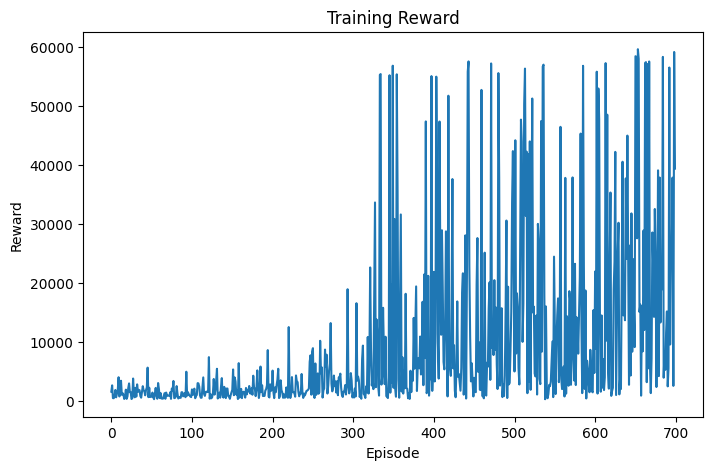

In [52]:
plt.figure(figsize=(8,5))

plt.plot(logger.episode_rewards)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward")

plt.show()

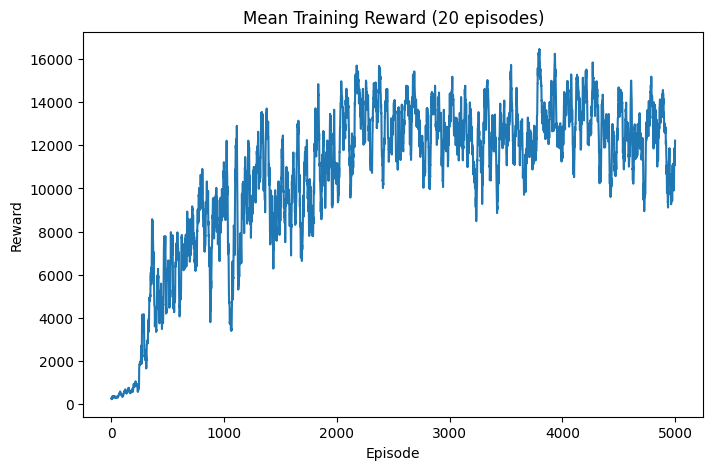

In [19]:
plt.figure(figsize=(8,5))

plt.plot(logger.mean_rewards)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Mean Training Reward (20 episodes)")

plt.show()

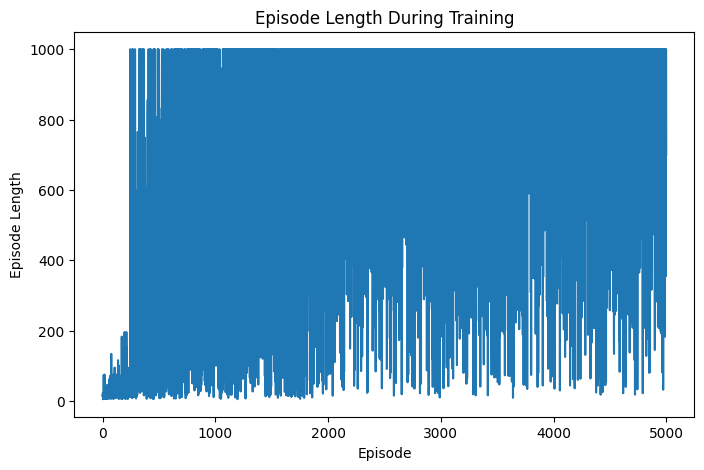

In [20]:
plt.figure(figsize=(8,5))

plt.plot(logger.episode_lengths)

plt.xlabel("Episode")
plt.ylabel("Episode Length")

plt.title("Episode Length During Training")

plt.show()

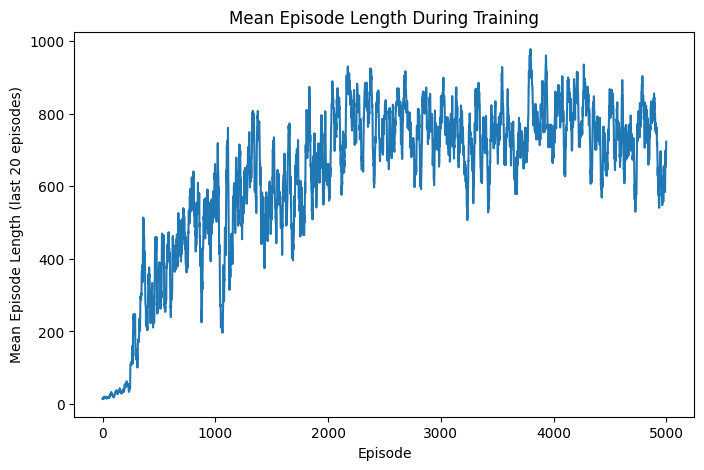

In [21]:
plt.figure(figsize=(8,5))

plt.plot(logger.mean_lengths)

plt.xlabel("Episode")
plt.ylabel("Mean Episode Length (last 20 episodes)")

plt.title("Mean Episode Length During Training")

plt.show()

## Policy Evaluation

We now evaluate the trained policy on a single episode.

Episode statistics will be displayed during execution.

In [ ]:
#from stable_baselines3 import PPO
#import os

## chemin vers le modèle
#MODEL_PATH = "models/ppo_highway.zip"

## vérification que le fichier existe
#if not os.path.exists(MODEL_PATH):
#    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

## chargement du modèle
#model = PPO.load(MODEL_PATH)

#print("Model loaded successfully.")

In [23]:
env_eval = make_env(ENV_CONFIG, reward_config=REWARD_CONFIG)

obs, _ = env_eval.reset()

done = False

total_reward = 0
speeds = []

step = 0

while not done:

    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env_eval.step(action)

    speed = env_eval.unwrapped.vehicle.speed
    speeds.append(speed)

    total_reward += reward
    step += 1

    print(
        f"Step {step} | "
        f"Speed {speed:.2f} | "
        f"Reward {reward:.2f}"
    )

    done = terminated or truncated

print("\nEpisode finished")
print("Total reward:", total_reward)

Step 1 | Speed 22.22 | Reward 19.31
Step 2 | Speed 20.99 | Reward 17.36
Step 3 | Speed 20.44 | Reward 16.44
Step 4 | Speed 20.20 | Reward 15.96
Step 5 | Speed 20.09 | Reward 15.66
Step 6 | Speed 20.04 | Reward 16.06
Step 7 | Speed 20.02 | Reward 16.03
Step 8 | Speed 20.01 | Reward 16.01
Step 9 | Speed 20.00 | Reward 16.01
Step 10 | Speed 20.00 | Reward 16.00
Step 11 | Speed 20.00 | Reward 16.00
Step 12 | Speed 20.00 | Reward 16.00
Step 13 | Speed 20.00 | Reward 16.00
Step 14 | Speed 20.00 | Reward 16.00
Step 15 | Speed 20.00 | Reward 16.00
Step 16 | Speed 20.00 | Reward 16.00
Step 17 | Speed 20.00 | Reward 16.00
Step 18 | Speed 20.00 | Reward 16.00
Step 19 | Speed 20.00 | Reward 16.00
Step 20 | Speed 20.00 | Reward 16.00
Step 21 | Speed 20.00 | Reward 16.00
Step 22 | Speed 20.00 | Reward 16.00
Step 23 | Speed 20.00 | Reward 16.00
Step 24 | Speed 20.00 | Reward 16.00
Step 25 | Speed 20.00 | Reward 16.00
Step 26 | Speed 20.00 | Reward 16.00
Step 27 | Speed 20.00 | Reward 16.00
Step 28 | 

## Speed Distribution

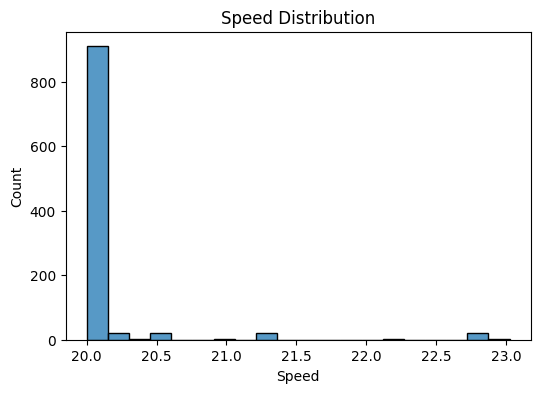

In [53]:
plt.figure(figsize=(6,4))

sns.histplot(speeds, bins=20)

plt.xlabel("Speed")
plt.title("Speed Distribution")

plt.show()

## Phase Diagram

The phase diagram shows the relationship between vehicle speed and the distance to the closest vehicle.

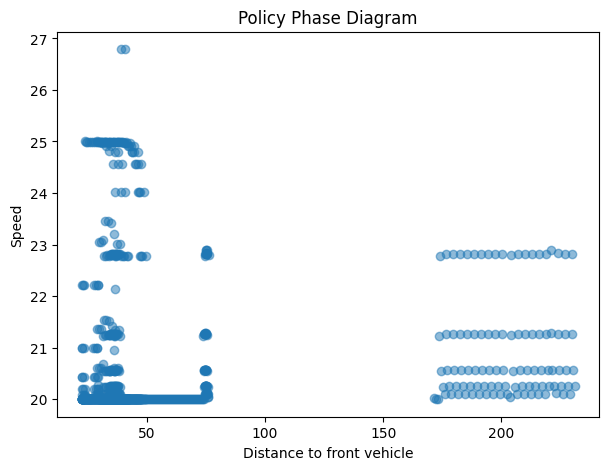

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def distance_to_front_vehicle(env):
    ego = env.unwrapped.vehicle
    vehicles = env.unwrapped.road.vehicles

    same_lane_front_distances = []

    for veh in vehicles:
        if veh is ego:
            continue

        # même voie
        if veh.lane_index == ego.lane_index:
            # distance longitudinale approximative
            dx = veh.position[0] - ego.position[0]

            # seulement les véhicules devant
            if dx > 0:
                same_lane_front_distances.append(dx)

    if len(same_lane_front_distances) == 0:
        return np.nan

    return min(same_lane_front_distances)


distances = []
speeds = []

env_eval = make_env(ENV_CONFIG, reward_config)
obs, _ = env_eval.reset()

done = False

while not done:
    ego = env_eval.unwrapped.vehicle

    d_front = distance_to_front_vehicle(env_eval)
    distances.append(d_front)
    speeds.append(ego.speed)

    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_eval.step(action)

    done = terminated or truncated

distances = np.array(distances)
speeds = np.array(speeds)

mask = ~np.isnan(distances)

plt.figure(figsize=(7, 5))
plt.scatter(distances[mask], speeds[mask], alpha=0.5)
plt.xlabel("Distance to front vehicle")
plt.ylabel("Speed")
plt.title("Policy Phase Diagram")
plt.show()